<a href="https://colab.research.google.com/github/riyaashukla30/AI-ML-Assignment-1/blob/main/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Medical Insurance Cost Prediction using Multiple Linear Regression

## AI-ML Assignment 1

### Name: Riya Shukla
### Registration Number: 23BCE11293
### Application Number: IN26012655
### Batch Number: 2(B)

---
### Problem Statement

The objective of this project is to develop a Multiple Linear Regression model that predicts medical insurance charges based on customer information such as age, sex, BMI, number of children, smoking status, and region. This helps insurance companies estimate insurance costs more accurately.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Step 1: Load the Dataset


In [3]:
from google.colab import files

uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [4]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Step 2: Data Understanding


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
print("Numerical Features:")
print(df.select_dtypes(include=["int64","float64"]).columns)

print()

print("Categorical Features:")
print(df.select_dtypes(include=["object"]).columns)

print()

print("Target Variable:")
print("charges")

Numerical Features:
Index(['age', 'bmi', 'children', 'charges'], dtype='object')

Categorical Features:
Index(['sex', 'smoker', 'region'], dtype='object')

Target Variable:
charges


### Observation

Numerical Features:
- age
- bmi
- children
- charges

Categorical Features:
- sex
- smoker
- region

Target Variable:
- charges

# Step 3: Data Preprocessing

In [7]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


### Observation

The dataset does not contain any missing values.

In [8]:
le = LabelEncoder()

df["sex"] = le.fit_transform(df["sex"])
df["smoker"] = le.fit_transform(df["smoker"])
df["region"] = le.fit_transform(df["region"])

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


### Encoded Variables

- sex
- smoker
- region

In [9]:
X = df.drop("charges", axis=1)

y = df["charges"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Step 4: Model Development

In [11]:
model = LinearRegression()

In [12]:
model.fit(X_train, y_train)

LinearRegression()

In [13]:
y_pred = model.predict(X_test)

In [14]:
y_pred = model.predict(X_test)

# Step 5: Model Evaluation

In [15]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 4186.508898366433
Mean Squared Error: 33635210.431178406
R2 Score: 0.7833463107364539


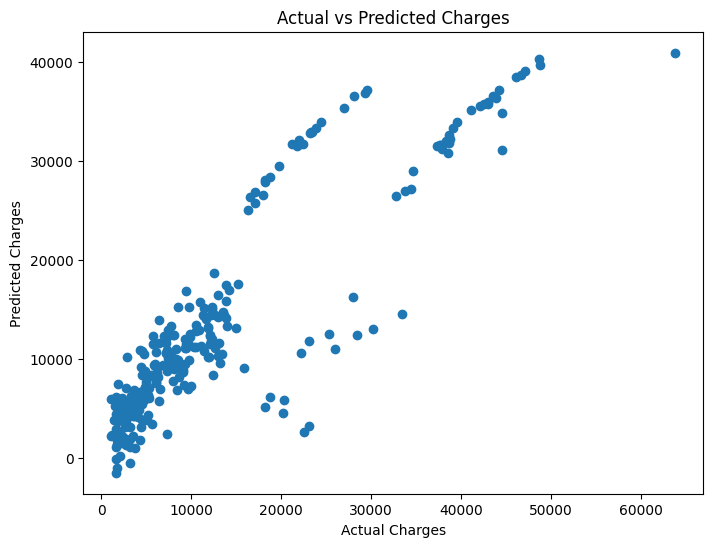

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted Charges")

plt.show()

### Observations

1. The predicted insurance charges are close to the actual charges for many customers.
2. Some predictions differ from the actual values, indicating prediction errors for certain cases.
3. The R² score shows how well the model explains the variation in insurance charges.

# Conclusion

The Multiple Linear Regression model was developed to predict medical insurance charges using features such as age, sex, BMI, number of children, smoking status, and region. The model successfully learned the relationship between these factors and insurance costs. Among all the features, smoking status and BMI have a significant impact on insurance charges. The model achieved reasonable performance based on MAE, MSE, and R² score. However, Linear Regression assumes a linear relationship between the features and the target variable, which may not always capture complex real-world patterns. More advanced machine learning models could improve prediction accuracy.